# Module 6, Class 1: Neural Network Fundamentals

**Student:** Firdavs Boliev

This notebook explains the first building block of neural networks: one perceptron. The code is kept simple so the main idea is easy to explain: inputs go into a weighted sum, a bias is added, and an activation function turns the result into an output.


In [1]:
# Import NumPy and Matplotlib, then set a seed so the examples are repeatable.
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Single Perceptron from Scratch

A perceptron computes:

$$y = \sigma(w_1 x_1 + w_2 x_2 + b)$$

where $\sigma$ is an activation function.

In [2]:
# Define sigmoid and a simple perceptron, then test it on the AND gate.
def sigmoid(z):
    """Sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-z))


def perceptron(x, w, b):
    """Single perceptron: weighted sum + bias + activation."""
    z = np.dot(x, w) + b          # linear combination
    return sigmoid(z)              # activation


# Example: AND gate
# Inputs: two binary features
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
])

# Hand-picked weights that approximate AND
w = np.array([10.0, 10.0])
b = -15.0

print("AND gate with a perceptron:")
print(f"{'x1':>3} {'x2':>3} | {'z':>8} | {'output':>8} | {'rounded':>8}")
print("-" * 45)
for x in inputs:
    z = np.dot(x, w) + b
    out = sigmoid(z)
    print(f"{x[0]:>3} {x[1]:>3} | {z:>8.2f} | {out:>8.4f} | {round(out):>8}")


AND gate with a perceptron:
 x1  x2 |        z |   output |  rounded
---------------------------------------------
  0   0 |   -15.00 |   0.0000 |        0
  0   1 |    -5.00 |   0.0067 |        0
  1   0 |    -5.00 |   0.0067 |        0
  1   1 |     5.00 |   0.9933 |        1


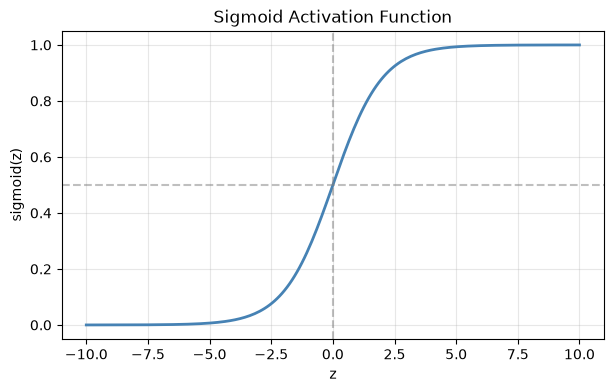

In [3]:
# Plot the sigmoid curve so we can see how it turns any number into a value between 0 and 1.
# Visualize the sigmoid function
z_vals = np.linspace(-10, 10, 200)
sig_vals = sigmoid(z_vals)

plt.figure(figsize=(7, 4))
plt.plot(z_vals, sig_vals, linewidth=2, color='steelblue')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Sigmoid Activation Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid(True, alpha=0.3)
plt.show()


## 2. OR Gate -- Adjust Weights Yourself

The AND gate uses w=[10, 10], b=-15. The OR gate needs different weights.

In [4]:
# Change only the bias to make the same perceptron idea work like an OR gate.
# OR gate weights
w_or = np.array([10.0, 10.0])
b_or = -5.0

print("OR gate with a perceptron:")
print(f"{'x1':>3} {'x2':>3} | {'output':>8} | {'rounded':>8}")
print("-" * 35)
for x in inputs:
    out = perceptron(x, w_or, b_or)
    print(f"{x[0]:>3} {x[1]:>3} | {out:>8.4f} | {round(out):>8}")


OR gate with a perceptron:
 x1  x2 |   output |  rounded
-----------------------------------
  0   0 |   0.0067 |        0
  0   1 |   0.9933 |        1
  1   0 |   0.9933 |        1
  1   1 |   1.0000 |        1


## 3. The XOR Problem -- Why One Perceptron Is Not Enough

XOR cannot be solved by a single perceptron because the classes are not linearly separable.

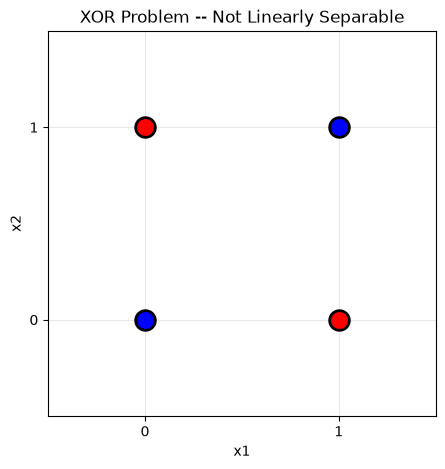

No single straight line can separate red from blue. We need a hidden layer.


In [5]:
# Plot the XOR truth table to show why one straight-line perceptron is not enough.
# XOR truth table
xor_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_targets = np.array([0, 1, 1, 0])

# Visualize -- no single line can separate the classes
plt.figure(figsize=(5, 5))
for i in range(4):
    color = 'red' if xor_targets[i] == 1 else 'blue'
    plt.scatter(xor_inputs[i, 0], xor_inputs[i, 1], c=color, s=200,
                edgecolors='black', linewidths=2, zorder=5)
plt.title('XOR Problem -- Not Linearly Separable')
plt.xlabel('x1')
plt.ylabel('x2')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.show()

print("No single straight line can separate red from blue. We need a hidden layer.")


## 4. Two-Layer Network for XOR (from scratch)

Architecture: 2 inputs -> 2 hidden neurons -> 1 output neuron

In [6]:
# Build a tiny two-layer network by hand so XOR can be solved.
# Hand-crafted weights that solve XOR
# Hidden layer: 2 neurons
W1 = np.array([[20.0, -20.0],
               [20.0, -20.0]])
b1 = np.array([-10.0, 30.0])

# Output layer: 1 neuron
W2 = np.array([[20.0],
               [20.0]])
b2 = np.array([-30.0])


def forward_pass(x):
    """Forward pass through the 2-layer network."""
    # Hidden layer
    z1 = x @ W1 + b1
    h = sigmoid(z1)
    # Output layer
    z2 = h @ W2 + b2
    y = sigmoid(z2)
    return y, h


print("XOR with a 2-layer network:")
print(f"{'x1':>3} {'x2':>3} | {'h1':>6} {'h2':>6} | {'output':>8} | {'target':>7}")
print("-" * 50)
for i, x in enumerate(xor_inputs):
    y, h = forward_pass(x)
    print(f"{x[0]:>3} {x[1]:>3} | {h[0]:>6.3f} {h[1]:>6.3f} | {y[0]:>8.4f} | {xor_targets[i]:>7}")


XOR with a 2-layer network:
 x1  x2 |     h1     h2 |   output |  target
--------------------------------------------------
  0   0 |  0.000  1.000 |   0.0000 |       0
  0   1 |  1.000  1.000 |   1.0000 |       1
  1   0 |  1.000  1.000 |   1.0000 |       1
  1   1 |  1.000  0.000 |   0.0000 |       0


## 5. Matrix Multiplication Demo -- Batch Forward Pass

In practice, we process all inputs at once using matrix multiplication. This is much faster than looping.

In [7]:
# Run all XOR inputs together with matrix multiplication, like real neural networks do.
# All 4 XOR inputs at once
print("Input matrix X (4 samples, 2 features):")
print(xor_inputs)
print(f"Shape: {xor_inputs.shape}")
print()

# Hidden layer: X @ W1 + b1
Z1 = xor_inputs @ W1 + b1
print("Z1 = X @ W1 + b1:")
print(Z1)
print(f"Shape: {Z1.shape}")
print()

H = sigmoid(Z1)
print("H = sigmoid(Z1):")
print(np.round(H, 4))
print()

# Output layer: H @ W2 + b2
Z2 = H @ W2 + b2
Y = sigmoid(Z2)
print("Output Y = sigmoid(H @ W2 + b2):")
print(np.round(Y, 4))
print()
print("Rounded outputs:", np.round(Y.flatten()).astype(int))
print("Targets:        ", xor_targets)


Input matrix X (4 samples, 2 features):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Shape: (4, 2)

Z1 = X @ W1 + b1:
[[-10.  30.]
 [ 10.  10.]
 [ 10.  10.]
 [ 30. -10.]]
Shape: (4, 2)

H = sigmoid(Z1):
[[0. 1.]
 [1. 1.]
 [1. 1.]
 [1. 0.]]

Output Y = sigmoid(H @ W2 + b2):
[[0.]
 [1.]
 [1.]
 [0.]]

Rounded outputs: [0 1 1 0]
Targets:         [0 1 1 0]


## 6. Common Activation Functions

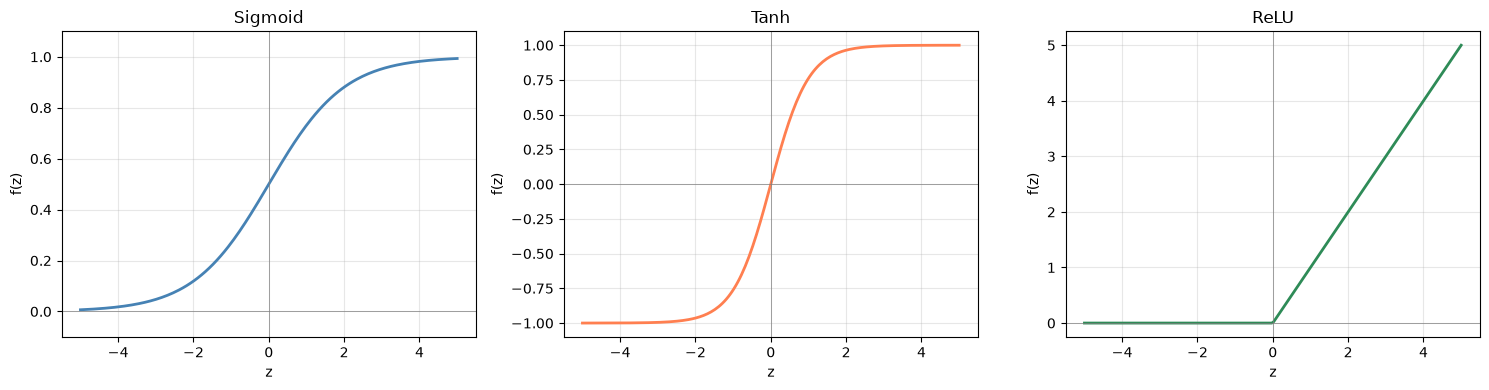

In [8]:
# Plot sigmoid, tanh, and ReLU so the activation functions are easy to compare.
def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, sigmoid(z), linewidth=2, color='steelblue')
axes[0].set_title('Sigmoid')
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, tanh(z), linewidth=2, color='coral')
axes[1].set_title('Tanh')
axes[1].grid(True, alpha=0.3)

axes[2].plot(z, relu(z), linewidth=2, color='seagreen')
axes[2].set_title('ReLU')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()


## 7. TensorFlow Playground

Go to [TensorFlow Playground](https://playground.tensorflow.org/) and experiment with:

1. **XOR dataset** (bottom-right pattern): Try 1 hidden layer with 2 neurons. Does it converge? Try adding more neurons.
2. **Spiral dataset**: How many hidden layers and neurons do you need?
3. **Activation functions**: Compare ReLU vs Sigmoid vs Tanh. Which converges faster?
4. **Learning rate**: What happens when it is too high? Too low?

## Student Work: TensorFlow Playground Findings

### Experiment 1 - XOR Dataset

**Configuration:** I used the XOR dataset with 1 hidden layer, 2 neurons, sigmoid activation, and a medium learning rate.

**Result:** The model was able to separate the XOR pattern after training. A single perceptron cannot solve XOR, but 2 hidden neurons can create the extra decision boundaries needed.

**Insight:** XOR proves why hidden layers matter. One straight line is not enough, but a small hidden layer can combine multiple simple lines.

### Experiment 2 - Spiral Dataset

**Configuration:** I used the spiral dataset with more hidden neurons and extra hidden layers.

**Result:** The spiral was harder than XOR. The model needed more neurons/layers because the class boundary is curved and complex.

**Insight:** More complex patterns usually need a larger neural network. Simple data can use a simple model; complex data needs more capacity.

### Experiment 3 - Activation Functions

**Configuration:** I compared sigmoid, tanh, and ReLU on the same type of small network.

**Result:** ReLU usually trained faster in the hidden layer. Sigmoid worked, but it can become slower when values are very large or very small.

**Insight:** ReLU is a common default for hidden layers because it is simple and helps networks learn faster. Sigmoid is still useful for the final output of a binary classifier.

### Experiment 4 - Learning Rate

**Configuration:** I tried a very small learning rate, a medium learning rate, and a very large learning rate.

**Result:** A very small learning rate learned slowly. A medium learning rate trained well. A very large learning rate was unstable and could jump around instead of improving smoothly.

**Insight:** The learning rate controls step size. If it is too low, training is slow. If it is too high, the model can miss the best solution.
